In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyro
import pyro.distributions as dist
import scipy
import torch
import torch.nn as nn

from pyro.nn import PyroModule, PyroSample
from pyro.infer import MCMC, NUTS, Predictive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils.BNN import BayesianNeuralNetwork
from utils.forecast import recursive_forecast
from utils.methods_2 import evaluate_metrics
from utils.Reservoir import Reservoir

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

### Collecting and preparing the data

In [3]:
# Load the MAT file for training and validation
mat_file = scipy.io.loadmat("data/100307.REST1.LR.SchaeferS.ptseries.mat")
data = torch.from_numpy(mat_file["tseries"]).float().t()
data = torch.Tensor(StandardScaler().fit_transform(data.numpy()))

In [4]:
time_steps = torch.arange(0, data.shape[0])
val_size = 0.15
test_size = 0.15
x_train, x_temp, time_steps_train, time_steps_temp = train_test_split(
    data, time_steps, test_size=(test_size + val_size), shuffle=False
)
x_val, x_test, time_steps_val, time_steps_test = train_test_split(
    x_temp,
    time_steps_temp,
    test_size=(test_size / (val_size + test_size)),
    shuffle=False,
)

### Defining the reservoir

In [5]:
dim_reservoir = 50
num_features = data.shape[1]
reservoir = Reservoir(dim_reservoir, num_features)

In [6]:
# |x | states |
# |train 0|train 1|
# |train 1|train 2|
# ...
# |train M-1|train M|
# |train M|val 0|
# |val 0|val 1|
# ...
# |val N-1|val N|
# |val N|test 0|
# |test 0|test 1|
# ...
# |test P-1|test P|
# |test P|discarded|

In [7]:
# we first have to generate all the states of the resevoir
# keep in mind that the state of the last item in a set
# is the first item for the next set when
states_train = torch.zeros((x_train.shape[0] - 1, dim_reservoir))
states_val = torch.zeros((x_val.shape[0], dim_reservoir))
states_test = torch.zeros((x_test.shape[0], dim_reservoir))

# let's start with the train points
for t, x in enumerate(x_train[:-1]):
    states_train[t, :] = reservoir(x)
states_val[0, :] = reservoir(x_train[-1])

# we want to save the state that marks the beginning of the val set
reservoir.save_state("val_start")

# now the validation points
for t, x in enumerate(x_val[:-1]):
    states_val[t + 1, :] = reservoir(x)
states_test[0, :] = reservoir(x_val[-1])

# same for test set
reservoir.save_state("test_start")

# the last test point is discarded
for t, x in enumerate(x_test[:-1]):
    states_test[t + 1, :] = reservoir(x)

### Defining the BNN

In [ ]:
num_layers = 3
layer_sizes = [
    int(layer_size)
    for layer_size in np.linspace(dim_reservoir, num_features, num_layers)
]
# layer_sizes = [dim_reservoir, dim_reservoir // 2, 10, num_features // 2, num_features]
model = BayesianNeuralNetwork(layer_sizes, nn.ReLU()).to(device)

In [9]:
# mcmc hyperparameters
warmup_steps = 100
num_samples = 100

# mcmc
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=num_samples, warmup_steps=warmup_steps)

In [10]:
# running the mcmc chain with the train sets
# keep in mind that the first point of x has to be discarded
# since there is no corresponding state
mcmc.run(states_train.to(device), x_train[1:].to(device))

Sample: 100%|██████████| 200/200 [20:41,  6.21s/it, step size=5.48e-04, acc. prob=0.828]


In [11]:
# define a predictive model from the posterior samples
predictive = Predictive(model, mcmc.get_samples())

In [12]:
# let's test on the validation set
pred = predictive(states_val)
y_val = pred["obs"]

In [13]:
def plot_val(t_val, x_val, y_val):
    avg = torch.mean(y_val, dim=0)
    std = torch.std(y_val, dim=0)
    fig, ax = plt.subplots()
    ax.plot(t_val, x_val)
    ax.plot(t_val, avg, color="r", linestyle="--")
    ax.fill_between(t_val, avg - std, avg + std, color="r", alpha=0.5)
    plt.show()
    return

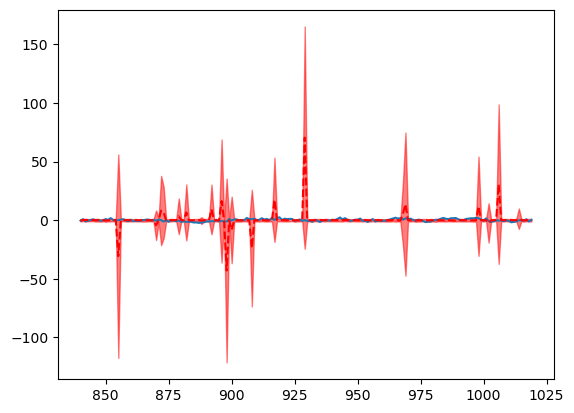

In [14]:
feature = 70
plot_val(time_steps_val, x_val[:, feature], y_val[:, :, feature])

In [ ]:
ecov, cal, mcrps = evaluate_metrics(y_val, x_val)

### Forecast

In [18]:
# forecast hyperparameters
iterations = 50
n_chains = 50

# we now go back to the start of the test set
reservoir.load_state("test_start")
forecast_chains = recursive_forecast(
    x_test[0][None, :], predictive, reservoir, iterations=iterations, n_chains=n_chains
)

In [17]:
x_test[0].shape

torch.Size([119])